<a href="https://www.kaggle.com/code/sonawanelalitsunil/mobile-laptop-sales-overview-ml-20-72?scriptVersionId=233207416" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mobiles-and-laptop-sales-data/mobile_sales_data.csv


### Title: Mobile & Laptop Sales Overview

#### Description: A summary of sales performance for mobile phones and laptops, highlighting key trends, units sold, and revenue insights.

## Import dataset

In [2]:
df= pd.read_csv('/kaggle/input/mobiles-and-laptop-sales-data/mobile_sales_data.csv')

In [3]:
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


In [4]:
df.tail()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
49995,Laptop,Motorola,8C187637,Pick build kind teach mean each camera.,170385,2024-03-02,2024-04-11,6,Sara Gomez,Sylviatown,North,i3,i3,16GB,512GB,2TB
49996,Laptop,HP,0DA9E4D3,Outside policy treat he opportunity pattern.,193133,2025-01-19,2025-01-20,4,Raymond Clark,Chrismouth,West,i7,i7,8GB,1TB,512GB
49997,Laptop,Toshiba,CAD89A93,Test floor tax together out adult discover own...,66502,2024-01-16,2024-03-05,6,Joseph Martin,Huntfurt,North,i5,i5,4GB,64GB,2TB
49998,Mobile Phone,Lenovo,78566C17,Away also magazine receive such lay.,158883,2023-05-15,2023-05-25,2,Gabrielle Barnett,Heidiberg,North,NaN,Snapdragon 7s,12GB,1TB,NaN
49999,Laptop,Asus,9C3FC57C,Role ahead common listen idea few blood half.,86483,2023-08-29,2023-10-26,7,Robert Sampson,West Elizabethchester,East,i7,i7,12GB,128GB,256GB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-null  object
 6   Dispatch Date            50000 non-null  object
 7   Quantity Sold            50000 non-null  int64 
 8   Customer Name            50000 non-null  object
 9   Customer Location        50000 non-null  object
 10  Region                   50000 non-null  object
 11  Core Specification       25017 non-null  object
 12  Processor Specification  50000 non-null  object
 13  RAM                      50000 non-null  object
 14  ROM                      50000 non-nul

In [6]:
df.describe()

,Price,Quantity Sold
count,50000.000000,50000.00000
mean,102641.407080,5.51378
std,56363.550361,2.88101
min,5008.000000,1.00000
25%,53487.000000,3.00000
50%,103072.000000,6.00000
75%,151396.250000,8.00000
max,199999.000000,10.00000


In [7]:
df.shape

(50000, 16)

In [8]:
df.isnull().sum()

Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum().sum()

49966

In [11]:
df.dtypes

Product                    object
Brand                      object
Product Code               object
Product Specification      object
Price                       int64
Inward Date                object
Dispatch Date              object
Quantity Sold               int64
Customer Name              object
Customer Location          object
Region                     object
Core Specification         object
Processor Specification    object
RAM                        object
ROM                        object
SSD                        object
dtype: object

In [12]:
df.columns

Index(['Product', 'Brand', 'Product Code', 'Product Specification', 'Price',
       'Inward Date', 'Dispatch Date', 'Quantity Sold', 'Customer Name',
       'Customer Location', 'Region', 'Core Specification',
       'Processor Specification', 'RAM', 'ROM', 'SSD'],
      dtype='object')

## Data visuliazations

In [13]:
# Drop rows with nulls in important columns
df.dropna(subset=['Price', 'Quantity Sold', 'Brand', 'Region'], inplace=True)

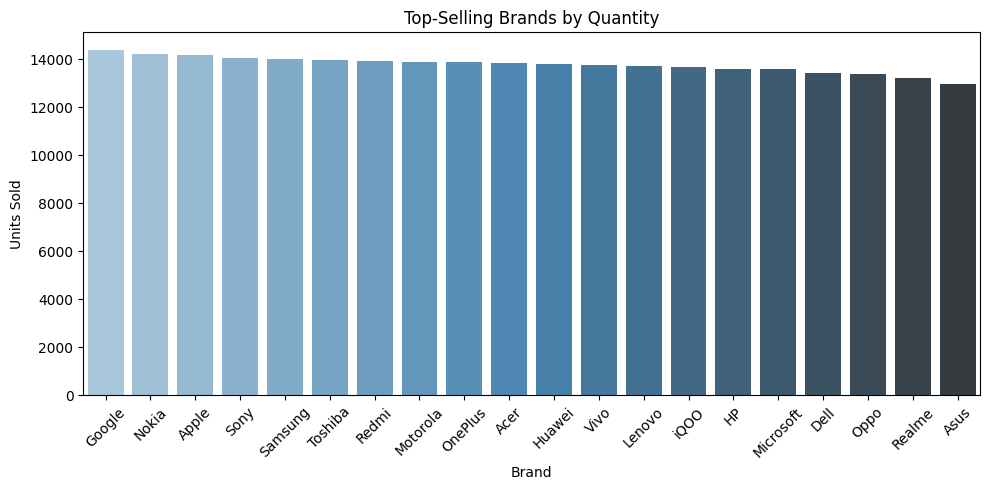

In [14]:
# 1. 📦 Top-selling brands by quantity
plt.figure(figsize=(10,5))
brand_sales = df.groupby('Brand')['Quantity Sold'].sum().sort_values(ascending=False)
sns.barplot(x=brand_sales.index, y=brand_sales.values, palette='Blues_d')
plt.title("Top-Selling Brands by Quantity")
plt.xticks(rotation=45)
plt.ylabel("Units Sold")
plt.xlabel("Brand")
plt.tight_layout()
plt.show()

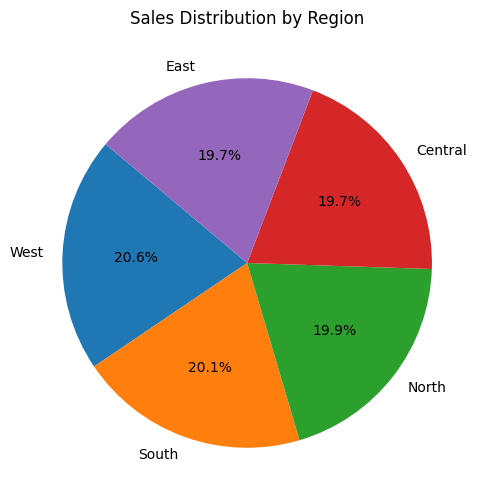

In [15]:
# 2. 🧭 Region-wise sales distribution
plt.figure(figsize=(6,6))
region_sales = df['Region'].value_counts()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Region")
plt.show()


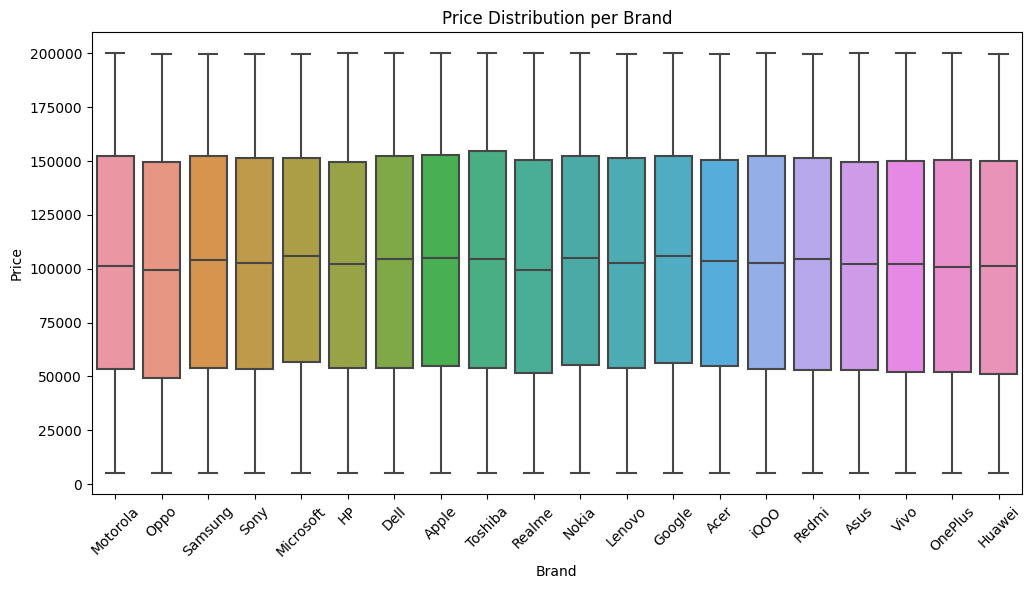

In [16]:
# 3. 💰 Boxplot of price by brand
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Brand', y='Price')
plt.title("Price Distribution per Brand")
plt.xticks(rotation=45)
plt.show()

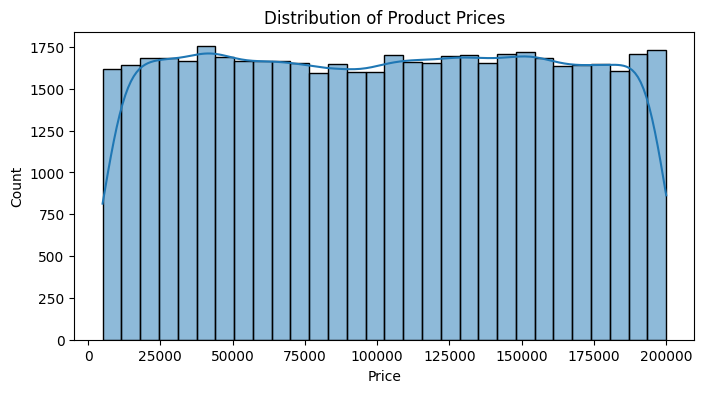

In [17]:
# 4. 🏷️ Histogram of product prices
plt.figure(figsize=(8,4))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.show()

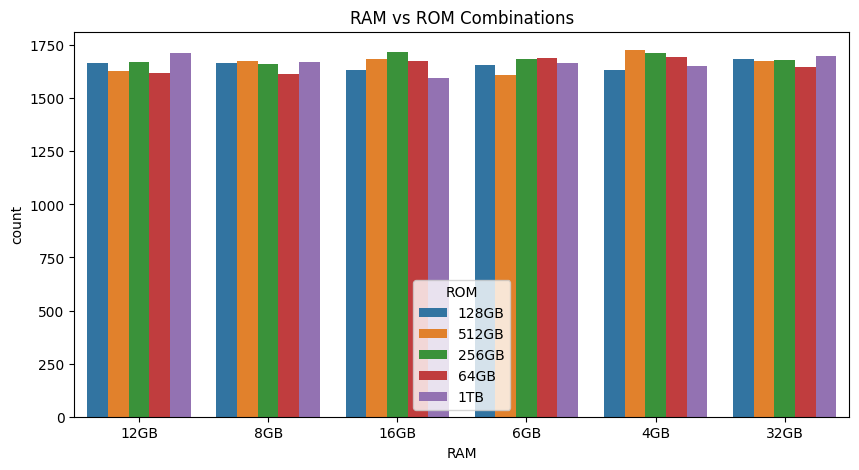

In [18]:
# 5. 📊 RAM vs ROM combinations
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='RAM', hue='ROM')
plt.title("RAM vs ROM Combinations")
plt.legend(title='ROM')
plt.show()

In [19]:
def clean_storage_column(col):
    return df[col].astype(str).str.upper().replace('TB', '000').str.extract('(\d+)').astype(float)

df['RAM'] = clean_storage_column('RAM')
df['ROM'] = clean_storage_column('ROM')
df['SSD'] = clean_storage_column('SSD')


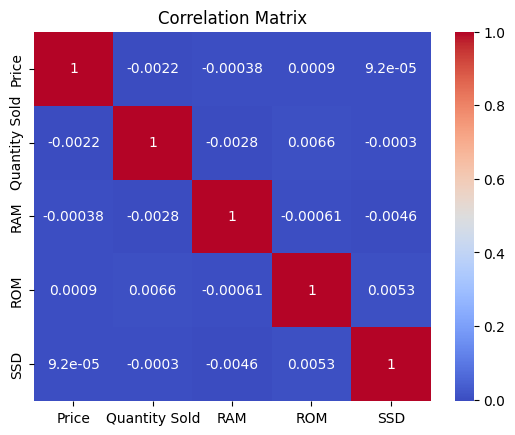

In [20]:
# 6. 🔥 Correlation heatmap
numeric_cols = ['Price', 'Quantity Sold', 'RAM', 'ROM', 'SSD']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [22]:
# List of columns we want to drop (if they exist)
drop_cols = ['Product Code', 'Customer Name', 'Inward Date', 'Dispatch Date']

# Drop only if they exist
existing_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=existing_cols)


In [23]:
# Handle missing values
df = df.dropna()

In [24]:
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:

# Define X and y
X = df.drop('Region', axis=1)
y = df['Region']


In [26]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier()
}



Logistic Regression
Accuracy: 20.44%


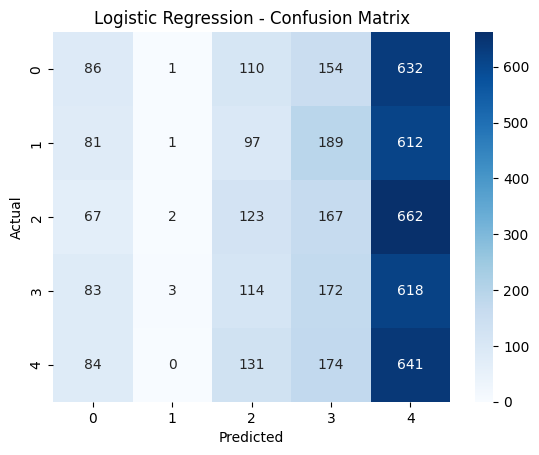


Random Forest
Accuracy: 19.84%


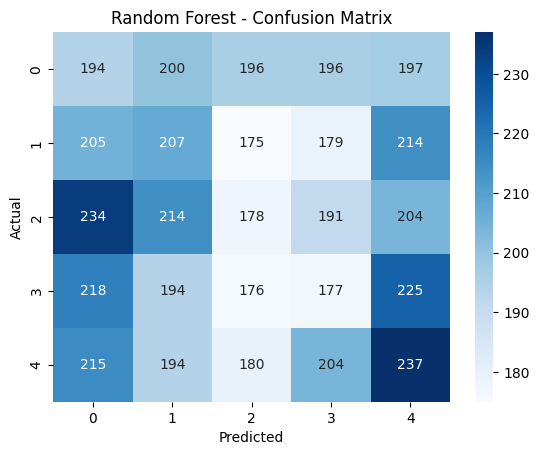


Decision Tree
Accuracy: 20.04%


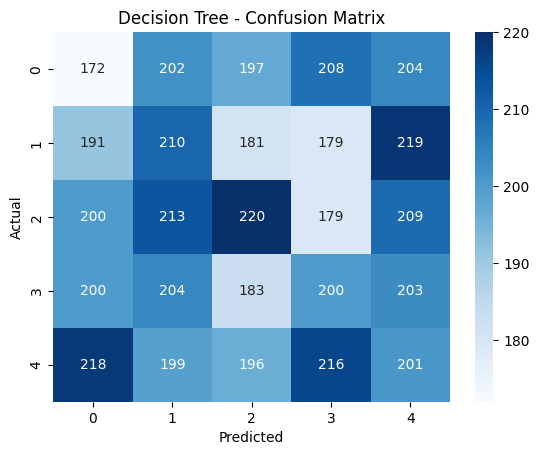


KNN
Accuracy: 20.08%


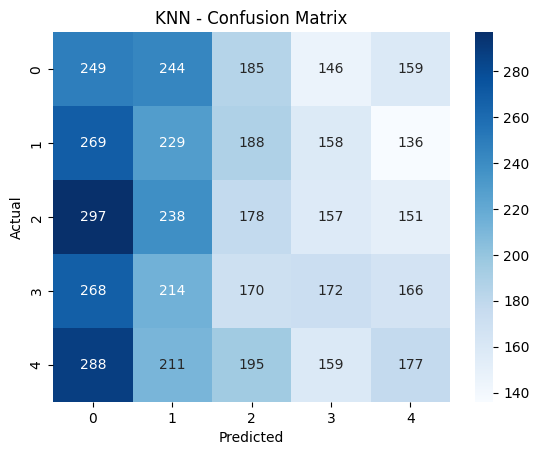


SVM
Accuracy: 20.72%


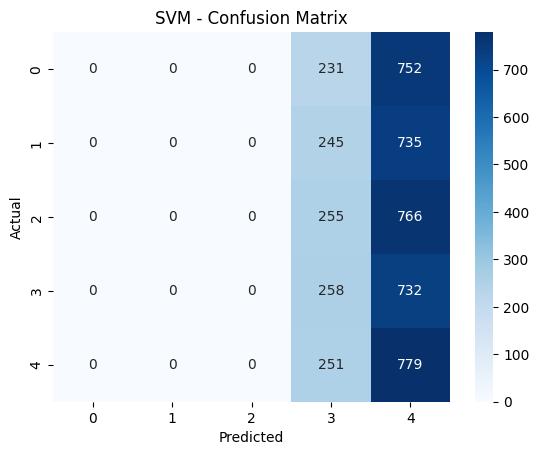


Gradient Boosting
Accuracy: 18.90%


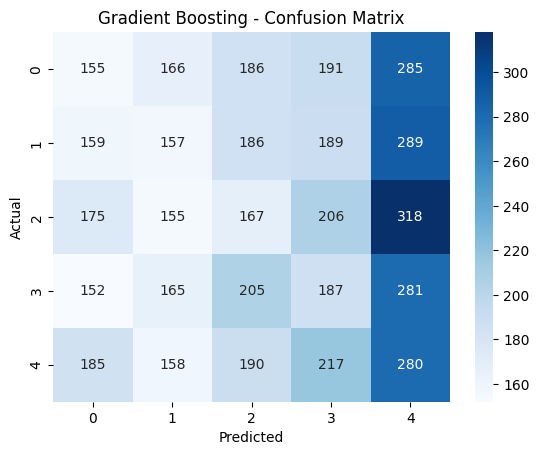

In [28]:
# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    print(f"\n{name}")
    print(f"Accuracy: {acc * 100:.2f}%")
    
    # Confusion matrix plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Thank you...pls upvote!!!